# Forward and Backward Propagation

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Run a **forward pass** through a small model and compute the loss
- Run **backward pass** (backprop) to compute gradients and perform one weight update
- See how loss changes after one update (optional small plot)

---

## 🌍 Real life

**Where is this used?** Every neural network training step uses **forward pass** (input → output → loss) and **backward pass** (gradients → weight updates). This is the core of how models learn in production and research.

**In this notebook we use** **forward propagation** to compute predictions and loss, and **backward propagation** to compute gradients and update weights. We use **GradientTape** (instead of writing derivatives by hand) **because** TensorFlow/PyTorch automate backprop so we can focus on architecture and data.

**📌 Covers slide(s):** Part of Unit 1 sequence (forward/backprop). *Do with or after 05_backpropagation_detailed; then 06_optimization_techniques.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **Forward pass:** Input → layer 1 → activation → … → output → loss. We compute the loss given current weights.
- **Backward pass (backprop):** We compute gradients of the loss w.r.t. each weight using the chain rule; the framework (e.g. TensorFlow) does this automatically with GradientTape.
- **Update:** Optimizer uses gradients to update weights (e.g. w -= lr * gradient).
- **We use GradientTape** instead of manual derivatives because it scales to large models and is less error-prone.

## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow. We use a tiny batch of MNIST (e.g. 32 samples) so one forward + backward step is fast.

**Dataset:** Real — MNIST (tiny batch for forward/backward demo).

**Outputs:** Printed loss before and after one update; optional bar chart showing "Loss before" vs "Loss after one update".

## Step 1: Imports and load a tiny batch

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if not HAS_TF:
    print("Install TensorFlow: pip install tensorflow")
else:
    (x_train, y_train), _ = tf.keras.datasets.mnist.load_data()
    x_train = tf.constant(x_train.astype(np.float32) / 255.0)
    x_train = tf.reshape(x_train, (-1, 784))[:32]
    y_train = tf.constant(y_train[:32])
    print("Batch shape:", x_train.shape)

Batch shape: (32, 784)


## Step 2: Build a small model and compute loss (forward pass)

In [2]:
if HAS_TF:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=(784,)),
        tf.keras.layers.Dense(10, activation="softmax"),
    ])
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()

    with tf.GradientTape() as tape:
        logits = model(x_train, training=True)
        loss_before = loss_fn(y_train, logits)
    grads = tape.gradient(loss_before, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    logits_after = model(x_train, training=False)
    loss_after = loss_fn(y_train, logits_after)

    loss_before_val = float(loss_before.numpy())
    loss_after_val = float(loss_after.numpy())
    print("Loss before one update: %.4f" % loss_before_val)
    print("Loss after one update:  %.4f" % loss_after_val)

Loss before one update: 2.5133
Loss after one update:  2.4749


## Step 3: Visualize loss before vs after one update

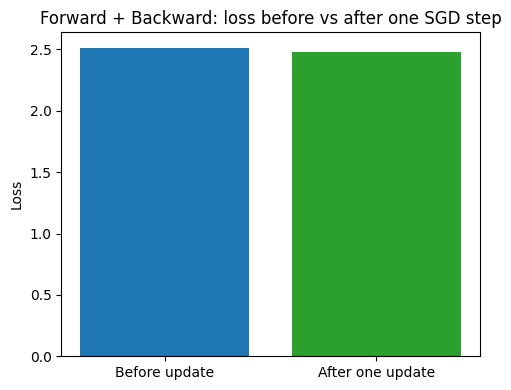

Backprop computed gradients; optimizer applied one step. Loss typically decreases.


In [3]:
if HAS_TF:
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(["Before update", "After one update"], [loss_before_val, loss_after_val], color=["#1f77b4", "#2ca02c"])
    ax.set_ylabel("Loss")
    ax.set_title("Forward + Backward: loss before vs after one SGD step")
    plt.tight_layout()
    plt.show()
    print("Backprop computed gradients; optimizer applied one step. Loss typically decreases.")

## 🧩 Mini-exercise

**Try it:** Run the training step (optimizer step) two more times in a new cell (same batch). Print the loss after each step. Does it keep decreasing?

---

## ✅ Summary

**What you did:**
- Ran a forward pass (input → model → loss) and backward pass (GradientTape → gradients → optimizer step).
- Compared loss before and after one update and plotted it.

**In real life you'd also:** Run many epochs, use validation loss, and save checkpoints.

**The main idea:** Training = repeat (forward → loss → backprop → update). Frameworks automate backprop so we don't write derivatives by hand.

**Next:** `05_backpropagation_detailed` goes deeper into how gradients flow; `06_optimization_techniques` compares optimizers.